---

## 메모리 추가

세션 간 사용자 정보를 유지하는 영구 상태 관리를 추가합니다. 메모리 기능을 통해 챗봇이 이전 대화 내용을 기억하고, 사용자별로 개인화된 응답을 제공할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Persistence](https://docs.langchain.com/oss/python/langgraph/persistence.md)

- 단기기억 : 세션 한정
- 장기기억 : 계정 단위

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Checkpointer | 그래프 실행 중 상태를 저장하고 복원하는 컴포넌트 |
| Thread ID | 동일 세션을 식별하는 고유 식별자 |
| User ID | 사용자별 장기 기억을 관리하는 식별자 |
| Persistent State | 누적된 대화 이력 기반의 컨텍스트 |

아래 코드는 메모리 추출을 위한 Pydantic 모델과 추출기를 정의합니다.

In [1]:
from usecase.SimpleLongTermMemory import SimpleLongTermMemory

graph = SimpleLongTermMemory()

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


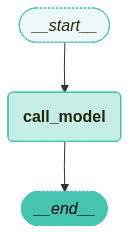

In [2]:
graph.show_graph()

In [3]:
def run_graph(
    graph,
    msg,
    thread_id="default",
    user_id="default",
):
    config = {
        "configurable": {
            "thread_id": thread_id + user_id,
            "user_id": user_id,
        }
    }
    print(f"\n[유저] {msg}")

    graph.stream(
        state={"messages": [{"role": "user", "content": msg}]},
        config=config,
    )

    print()

In [4]:
# 메시지, thread_id, user_id 전달
run_graph(graph,"안녕? 내 이름은 쥬카야", "1", "someone")


[유저] 안녕? 내 이름은 쥬카야
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕, 쥬카야! 만나서 반가워. 어떻게 지내고 있어?


In [5]:
# 메시지, thread_id, user_id 전달
run_graph(graph, "내 이름이 뭐라고?", "1", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
너의 이름은 쥬카야야! 맞지?


In [6]:
# 메시지, thread_id, user_id 전달
run_graph(graph, "내 이름이 뭐라고?", "2", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
죄송하지만, 당신의 이름은 알 수 없습니다. 하지만 필요한 정보나 질문이 있으면 도와드릴 수 있습니다! 무엇을 도와드릴까요?


In [7]:
# 메시지, thread_id, user_id 전달
run_graph(graph, "내 이름이 쥬카야 remember", "2", "someone")


[유저] 내 이름이 쥬카야 remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
```json
{
  "memories": [
    {
      "key": "user_name",
      "value": "쥬카",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    }
  ],
  "summary": "User identified themselves as '쥬카'.",
  "timestamp": "2023-10-23Tkey='user_name' value='쥬카' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
00:00:00Z"
}
```알겠습니다, 쥬카! 이제부터 당신의 이름을 기억할게요. 무엇을 도와드릴까요?


In [8]:
# 메시지, thread_id, user_id 전달
run_graph(graph, "내 이름이 뭐라고 했더라?", "1004", "someone")


[유저] 내 이름이 뭐라고 했더라?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
당신의 이름은 쥬카입니다! 어떻게 도와드릴까요?


In [9]:
# 메시지, thread_id, user_id 전달
run_graph(
    graph, "내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember", "4", "someone"
)


[유저] 내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
```json
{
  "memories": [
    {
      "key": "occupation",
      "value": "AI Engineer",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    },
    {
      "key": "hobby",
      "value": "Netflix 보기",
      "category": "preference",
      "importance": 4,
      "confidence": 1.0
    }
  ],
  "summary": "User is an AI Engineer and enjoys watching Netflix.",
  "timestamp": "2023-10-04T12:00:00Z"
}
```key='occupation' value='AI Engineer' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
key='hobby' value='Netflix 보기' category='preference' importance=4 confidence=1.0
----------------------------------------------------------------------------------------------------
내가 기억할 수는 없지만, 너의 직업이 AI 엔지니어이고 취미가 Ne

In [10]:
# 다른 스레드에서 실행
run_graph(graph, "내 이름, 직업, 취미 알려줘", "100", "someone")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
당신의 이름은 쥬카이고, 직업은 AI 엔지니어이며, 취미는 Netflix 보기입니다. 도움이 필요하시면 언제든지 말씀해 주세요!


### State 확인

저장된 상태를 조회하여 메시지 이력과 체크포인트 정보를 확인합니다. `get_state` 메서드를 통해 현재 상태의 스냅샷을 가져올 수 있습니다.

아래 코드는 특정 Config에 대한 현재 상태 정보를 조회합니다.

In [14]:
# 임의의 Config 설정
config = {
    "configurable": {
        "thread_id": "100" + "someone",
        "user_id": "someone",
    }
}

# 현재 상태 가져오기
# graph.graph 는 프로퍼티(컴파일된 그래프). 괄호 graph.graph() 는 호출 불가.
snapshot = graph.graph.get_state(config)

print("현재 상태 정보:")
print(f"- 메시지 수: {len(snapshot.values['messages'])}개")
print(f"- 체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")

# 최근 메시지 몇 개 표시
print("\n[최근 메시지]")
for msg in snapshot.values["messages"]:
    role = msg.type if hasattr(msg, "type") else "unknown"
    content = msg.content if hasattr(msg, "content") else str(msg)
    print(f"  [{role}]: {content}")

현재 상태 정보:
- 메시지 수: 2개
- 체크포인트 ID: 1f14e8da-15f4-6522-8001-4557f74e2da4

[최근 메시지]
  [human]: 내 이름, 직업, 취미 알려줘
  [ai]: 당신의 이름은 쥬카이고, 직업은 AI 엔지니어이며, 취미는 Netflix 보기입니다. 도움이 필요하시면 언제든지 말씀해 주세요!
